# G-Quadruplexes — SNP frequency (stem / loop sub-annotation)

SNP allele-frequency analysis around G-quadruplex (G4) motifs, reproducing the **stem / loop**
plotting logic of `Supplementary code 2.ipynb` section 1. Each G4 locus is sub-annotated into
**9 parts**:

```
LeftFlank | stem1 | loop1 | stem2 | loop2 | stem3 | loop3 | stem4 | RightFlank
```

The stem/loop partition of every motif **sequence** is computed with the published
`gee_kwad.py` parser (here ported to Python 3 as `gee_kwad_py3.py`; identical regex logic).
Only canonical G4s that parse into exactly **4 stems + 3 loops** are kept (matching the
reference `len == 7` filter). Stems are scaled to **30 bins**, loops to **20 bins**, and the
2 kb flanks keep 100 bp at single-bp resolution.

Two comparisons are produced, both using the **official IWTomics R Bioconductor package** for
the significance test and `ggplot2` for plotting (legend outside, matching the reference):

1. **detected G4 vs control** — gofae-detected G4s vs a shuffled genomic control (control loci
   carry the same motif sequences, so they have the same stem/loop structure at random
   positions).
2. **detected vs undetected vs control** — detected, the undetected complement (all-test G4
   ∖ detected), and the shuffled control.

All intermediate files live in `results/g4_stemloop_run/`.


# Library

Load this before running the rest of the notebook.

In [ ]:
# rpy2 is optional; the R plotting cells shell out to Rscript directly
try:
    get_ipython().run_line_magic('load_ext', 'rpy2.ipython')
    print('rpy2 loaded')
except Exception as e:
    print('rpy2 not available (expected; R plots call Rscript):', e)

In [ ]:
import os, sys, re, subprocess, random
from pathlib import Path
import pandas as pd
import numpy as np

BASE    = os.environ.get("SNP_AF_BASE", "/path/to/snp_af_analysis")
WORKDIR = f"{BASE}/results/g4_stemloop_run"
GEE     = f"{BASE}/gee_kwad_py3.py"          # py3 port of the published gee_kwad.py splitter
Path(WORKDIR).mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)

os.environ["BASE"]        = BASE
os.environ["CHROM_SIZES"] = f"{BASE}/reference/hg38.chrom.sizes"
os.environ["GAPS_BED"]    = f"{BASE}/annotations/hg38_gaps.bed"
os.environ["CODING_BED"]  = f"{BASE}/annotations/coding_regions.bed"
os.environ["REPEAT_BED"]  = f"{BASE}/annotations/repetitive_elements.bed"
os.environ["SNP_DIR"]     = f"{BASE}/snp_data/gnomad"
os.environ["PATH"]        = os.environ.get("BEDTOOLS_BIN", "") + ":" + os.environ["PATH"]
# Stage-1 (NR-Contrastive) outputs and experimental splits
# Override with environment variables; the defaults are the paths used for the paper.
PU_RESULTS      = os.environ.get("NONB_PU_RESULTS",
    "/path/to/pu_results")
EXPERIMENT_DATA = os.environ.get("NONB_EXPERIMENT_DATA",
    "/path/to/Experiment_Data")
IWTOMICS_DIR    = os.environ.get("IWTOMICS_DIR",
    "/path/to/nonb-nrcl-paper/snp_analysis/iwtomics")


random.seed(42); np.random.seed(42)

# + strand genomic sequence helper (the detected.bed `sequence` is the G-rich functional
# read; gee_kwad expects the + strand genomic sequence and reverse-complements for '-')
_COMP = str.maketrans("ACGTNacgtn", "TGCANtgcan")
def revcomp(s): return s.translate(_COMP)[::-1]

print("cwd:", os.getcwd())
print("bedtools:", subprocess.run("which bedtools", shell=True, capture_output=True, text=True).stdout.strip())

# G-Quadruplex stem/loop pipeline

NCNR filter → 100-bp motif-length threshold → 2 kb flanks → shuffled control → non-overlapping
window pick → `gee_kwad` stem/loop split → per-chromosome gnomAD intersect → per-locus matrices →
IWTomics permutation test (R) → 9-panel ggplot.

## 1 Retrieve annotation (detected) + build the motif BED

Load gofae-detected G4 motifs from `G_Quadruplex_Motif_detected.bed` (columns include `sequence`).
Coordinates are converted 1-based inclusive → 0-based half-open, and the **+ strand genomic
sequence** is stored (the bed `sequence` is the G-rich functional read, so it is
reverse-complemented for `-` strand motifs). Output 6-col BED: `chrom, start, end, gseq, length,
strand` — the exact input `gee_kwad` expects (`length == end - start == len(gseq)`).

In [ ]:
G4_BED = f"{PU_RESULTS}/G_Quadruplex_Motif/G_Quadruplex_Motif_detected.bed"

def write_motif_bed(df, out_bed):
    """df with chr, strand, motif_start (1-based), motif_end, and `gseq_plus`
    (the + strand GENOMIC sequence) -> 6-col gee_kwad bed: chrom,start,end,gseq,len,strand.
    gee_kwad reverse-complements internally for '-' strand, so gseq must be + strand genomic."""
    n = 0
    with open(out_bed, "w") as f:
        for chrom, strand, ms, me, gseq in zip(df["chr"], df["strand"],
                                               df["motif_start"], df["motif_end"], df["gseq_plus"]):
            s0 = int(ms) - 1; e = int(me); gseq = str(gseq).upper()
            if e - s0 != len(gseq):          # length must match for gee_kwad
                continue
            f.write(f"{chrom}\t{s0}\t{e}\t{gseq}\t{len(gseq)}\t{strand}\n")
            n += 1
    print(f"wrote {out_bed} with {n} rows")
    return n

g_df = pd.read_csv(G4_BED, sep="\t").dropna(subset=["motif_start", "motif_end"]).reset_index(drop=True)
g_df = g_df.drop_duplicates(subset=["chr", "motif_start", "motif_end", "strand"]).reset_index(drop=True)
print(f"detected G4 (deduped): {len(g_df)}")

# the detected.bed `sequence` is the G-rich functional read; convert to + strand genomic
g_df["gseq_plus"] = [s.upper() if st == "+" else revcomp(s.upper())
                     for s, st in zip(g_df["sequence"], g_df["strand"])]
write_motif_bed(g_df, "G4sl.motif.bed")

NCNR filter (remove overlaps with coding + repetitive) and apply the 100-bp motif-length threshold.

In [ ]:
%%bash
set -euo pipefail

if [ ! -f NCNR.hg38.bed ]; then
    cat "$CODING_BED" "$REPEAT_BED" | sort -k1,1 -k2,2n | bedtools merge -i stdin > NCNR.hg38.bed
fi

bedtools intersect -a G4sl.motif.bed -b NCNR.hg38.bed -v > G4sl.ncnr.bed
awk '{if ($3-$2<=100) print $0}' G4sl.ncnr.bed > G4sl.ncnr.100threshold.bed
bedtools sort -i G4sl.ncnr.100threshold.bed > G4sl.ncnr.sorted.bed

wc -l G4sl.motif.bed G4sl.ncnr.bed G4sl.ncnr.sorted.bed

## 2 Create Flanks

Add 2 kb flanks on each side, carrying the sequence/strand through. Output 8-col BED:
`chrom, flank_start, flank_end, strand, locus_start, locus_end, gseq, length`.

In [ ]:
%%bash
set -euo pipefail
paste G4sl.ncnr.sorted.bed \
    <(bedtools slop -i G4sl.ncnr.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $8, $9, $6, $2, $3, $4, $5}' \
  > G4sl.flanked.bed

wc -l G4sl.flanked.bed
head -2 G4sl.flanked.bed

## 3 Create Controls

Shuffle the NCNR-filtered loci to random genomic positions (exclusion = detected loci ∪ NCNR ∪
hg38 gaps), **carrying the motif sequence** so each control inherits its donor's stem/loop
structure but lands at a random location. `bedtools shuffle` preserves columns 4–6 and the
interval width, so `gseq`/`length`/`strand` stay valid.

In [ ]:
%%bash
set -euo pipefail

cut -f 1-3 G4sl.ncnr.sorted.bed > _t_g4sl
cat _t_g4sl "$GAPS_BED" NCNR.hg38.bed | cut -f1-3 \
  | sort -k1,1 -k2,2n | bedtools merge -i stdin > exclude_G4sl.bed

bedtools shuffle -i G4sl.ncnr.sorted.bed -excl exclude_G4sl.bed -g "$CHROM_SIZES" \
    -chrom -f 0 -noOverlapping -seed 42 > _t_g4sl_shuf
bedtools sort -i _t_g4sl_shuf > G4sl.shuffled.bed

paste G4sl.shuffled.bed \
    <(bedtools slop -i G4sl.shuffled.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $8, $9, $6, $2, $3, $4, $5}' \
  > G4sl.shuffled.flanked.bed

rm -f _t_g4sl _t_g4sl_shuf
wc -l G4sl.shuffled.flanked.bed
head -2 G4sl.shuffled.flanked.bed

## 4 Pick non-overlapping windows

Greedy pass that keeps one random motif per overlap cluster, removing pseudo-replication from the
4 kb flanked windows. Operates on the flanked BED (cols 1–3), carrying all 8 columns through.

In [ ]:
def locuschoice(in_bed, out_bed, seed=42):
    rng = random.Random(seed)
    last_chrom = "chr0"; last_end = 0; tochoose = []; nkept = 0
    with open(in_bed) as f_in, open(out_bed, "w") as f_out:
        for line in f_in:
            arr = line.rstrip("\n").split("\t")
            chrom = arr[0]; ws = int(arr[1]); we = int(arr[2])
            if chrom == last_chrom:
                if ws < last_end:
                    tochoose.append(arr); last_end = we
                else:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                    tochoose = [arr]; last_end = we
            else:
                if tochoose:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                tochoose = [arr]; last_chrom = chrom; last_end = we
        if tochoose:
            chosen = tochoose[rng.randint(0, len(tochoose)-1)]
            f_out.write("\t".join(chosen) + "\n"); nkept += 1
    print(f"{in_bed} -> {out_bed}: kept {nkept}")
    return nkept

locuschoice("G4sl.flanked.bed",          "G4sl.nooverlap.bed",          seed=42)
locuschoice("G4sl.shuffled.flanked.bed", "G4sl.shuffled.nooverlap.bed", seed=43)

## 5 Split into stem/loop sub-parts with `gee_kwad`

Each flanked window's motif sequence is parsed by `gee_kwad_py3.py` into stems and loops. The
locus is emitted as **9 rows** — `LeftFlank | stem1 | loop1 | stem2 | loop2 | stem3 | loop3 |
stem4 | RightFlank` — with a locus id. Only loci that parse into the canonical 4-stem/3-loop form
are kept (reference `len == 7`). Output 5-col split BED: `chrom, start, end, locus_id, part`.

In [ ]:
CENTER_ORDER = ["stem1", "loop1", "stem2", "loop2", "stem3", "loop3", "stem4"]

def split_g4_stemloop(flanked_bed, out_split_bed):
    """flanked_bed cols: chrom, flankstart, flankend, strand, locusstart, locusend, gseq, length.
    Runs gee_kwad_py3.py on the motif sequences and merges flanks + canonical stem/loop parts."""
    flank = {}
    geek_in = out_split_bed + ".geekin"
    with open(flanked_bed) as f, open(geek_in, "w") as gi:
        for line in f:
            a = line.rstrip("\n").split("\t")
            chrom, fs, fe, strand, ls, le, gseq, length = a[:8]
            flank[(chrom, ls, le, strand)] = (fs, fe)
            gi.write(f"{chrom}\t{ls}\t{le}\t{gseq}\t{length}\t{strand}\n")

    res = subprocess.run(["python3", GEE, "--allow:bulges", "--allow:Gloops", "--copyinput"],
                         stdin=open(geek_in), capture_output=True, text=True)

    kept = 0; cur_key = None; cur = []
    out = open(out_split_bed, "w")
    def flush():
        nonlocal kept, cur_key, cur
        if cur_key is not None and [p[3] for p in cur] == CENTER_ORDER and cur_key in flank:
            fs, fe = flank[cur_key]; chrom, ls, le, strand = cur_key
            out.write(f"{chrom}\t{fs}\t{ls}\t{kept}\tLeftFlank\n")
            for c, s, e, part in cur:
                out.write(f"{c}\t{s}\t{e}\t{kept}\t{part}\n")
            out.write(f"{chrom}\t{le}\t{fe}\t{kept}\tRightFlank\n")
            kept += 1
    for ln in res.stdout.splitlines():
        if ln.startswith("#"):
            flush(); cur = []; cur_key = None
            if "unable" in ln: continue
            a = ln[1:].strip().split()
            if len(a) >= 6: cur_key = (a[0], a[1], a[2], a[5])
        else:
            a = ln.split("\t")
            if len(a) >= 7 and cur_key is not None: cur.append((a[0], a[1], a[2], a[6]))
    flush(); out.close(); os.remove(geek_in)
    print(f"{flanked_bed} -> {out_split_bed}: kept {kept} canonical 4-stem loci")
    return kept

n_motif = split_g4_stemloop("G4sl.nooverlap.bed",          "G4sl.split.bed")
n_ctrl  = split_g4_stemloop("G4sl.shuffled.nooverlap.bed", "G4sl.shuffled.split.bed")
N_MOTIF, N_CTRL = n_motif, n_ctrl
print(f"\nN_MOTIF={N_MOTIF}  N_CTRL={N_CTRL}")
with open("split_counts.txt", "w") as f:
    f.write(f"N_MOTIF\t{N_MOTIF}\nN_CTRL\t{N_CTRL}\n")

## 6 Intersect annotations with gnomAD

Per-chromosome `bedtools intersect -loj` against `snp_data/gnomad/chr{N}_snps.bed`.

In [ ]:
def intersect_per_chrom(bed_path, out_path):
    snp_dir = os.environ["SNP_DIR"]
    chroms = sorted(pd.read_csv(bed_path, sep="\t", header=None)[0].unique())
    total = 0
    with open(out_path, "w") as fout:
        for c in chroms:
            snp_file = f"{snp_dir}/{c}_snps.bed"
            if not os.path.exists(snp_file):
                print(f"  skip {c} (no {snp_file})"); continue
            cmd = (f'awk \'$1=="{c}"\' {bed_path} '
                   f'| bedtools intersect -wa -wb -a stdin -b {snp_file} -loj')
            res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
            if res.stdout:
                fout.write(res.stdout); total += res.stdout.count("\n")
    print(f"{bed_path} -> {out_path}: {total} lines")
    return total

for p in ("G4sl.split.bed", "G4sl.shuffled.split.bed"):
    subprocess.run(f"bedtools sort -i {p} > _s.bed && mv _s.bed {p}", shell=True, check=True)

intersect_per_chrom("G4sl.split.bed",          "G4sl.gnomAD.intersect")
intersect_per_chrom("G4sl.shuffled.split.bed", "G4sl.gnomAD.shuffled.intersect")

## 7 Build the undetected G4 pool

Undetected = `label == 'G_Quadruplex_Motif'` rows from the test CSV minus the gofae-detected rows.
The test CSV has no `sequence` column, so each undetected locus's **+ strand genomic sequence** is
fetched from `hg38.fa` with `bedtools getfasta` (default = + strand), which is exactly what
`gee_kwad` expects. Same NCNR → threshold → flank → locuschoice → stem/loop split → intersect
pipeline as the detected set.

In [ ]:
# Undetected = all-test G4 minus detected. The test CSV lacks a sequence column, so we recover
# each undetected motif's sequence from the genome via bedtools getfasta.
TEST_CSV = f"{EXPERIMENT_DATA}/G_Quadruplex_Motif_test.csv"
HG38_FA  = f"{BASE}/reference/hg38.fa"

df_all = pd.read_csv(TEST_CSV, usecols=["chr","strand","motif_start","motif_end","label"])
df_all = df_all[df_all["label"] == "G_Quadruplex_Motif"].dropna(subset=["motif_start","motif_end"]).reset_index(drop=True)
df_all["motif_start"] = df_all["motif_start"].astype(int)
df_all["motif_end"]   = df_all["motif_end"].astype(int)
df_all = df_all.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)

df_det = pd.read_csv(G4_BED, sep="\t", usecols=["chr","strand","motif_start","motif_end"]).dropna(subset=["motif_start","motif_end"])
df_det["motif_start"] = df_det["motif_start"].astype(int)
df_det["motif_end"]   = df_det["motif_end"].astype(int)
df_det = df_det.drop_duplicates().assign(_is_det=True)

df_undet = df_all.merge(df_det, on=["chr","motif_start","motif_end","strand"], how="left")
df_undet = df_undet[df_undet["_is_det"].isna()].drop(columns=["_is_det"]).reset_index(drop=True)
print(f"all-test G4: {len(df_all)}, detected: {len(df_det)}, undetected: {len(df_undet)}")

# fetch + strand genomic sequence for each undetected locus (0-based half-open)
tmp_fa_bed = "G4sl.undet.fabed"
with open(tmp_fa_bed, "w") as f:
    for chrom, ms, me in zip(df_undet["chr"], df_undet["motif_start"], df_undet["motif_end"]):
        f.write(f"{chrom}\t{int(ms)-1}\t{int(me)}\n")
fa = subprocess.run(["bedtools", "getfasta", "-fi", HG38_FA, "-bed", tmp_fa_bed, "-tab"],
                    capture_output=True, text=True)
if fa.returncode != 0:
    print(fa.stderr); raise RuntimeError("bedtools getfasta failed")
seqs = [ln.split("\t")[1].upper() for ln in fa.stdout.splitlines()]
df_undet = df_undet.copy()
df_undet["gseq_plus"] = seqs           # + strand genomic sequence (getfasta default)
os.remove(tmp_fa_bed)

# build the 6-col gee_kwad motif bed (gseq is already + strand genomic)
write_motif_bed(df_undet, "G4sl.undet.motif.bed")

In [ ]:
%%bash
set -euo pipefail

bedtools intersect -a G4sl.undet.motif.bed -b NCNR.hg38.bed -v > G4sl.undet.ncnr.bed
awk '{if ($3-$2<=100) print $0}' G4sl.undet.ncnr.bed > G4sl.undet.ncnr.100threshold.bed
bedtools sort -i G4sl.undet.ncnr.100threshold.bed > G4sl.undet.ncnr.sorted.bed

paste G4sl.undet.ncnr.sorted.bed \
    <(bedtools slop -i G4sl.undet.ncnr.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $8, $9, $6, $2, $3, $4, $5}' \
  > G4sl.undet.flanked.bed

wc -l G4sl.undet.motif.bed G4sl.undet.ncnr.sorted.bed G4sl.undet.flanked.bed
head -2 G4sl.undet.flanked.bed

In [ ]:
# locuschoice + gee_kwad split + per-chrom gnomAD intersect (undetected)
locuschoice("G4sl.undet.flanked.bed", "G4sl.undet.nooverlap.bed", seed=44)

n_undet = split_g4_stemloop("G4sl.undet.nooverlap.bed", "G4sl.undet.split.bed")
N_UNDET = n_undet
print(f"\nN_UNDET={N_UNDET}")

subprocess.run("bedtools sort -i G4sl.undet.split.bed > _s.bed && mv _s.bed G4sl.undet.split.bed",
               shell=True, check=True)
intersect_per_chrom("G4sl.undet.split.bed", "G4sl.gnomAD.undet.intersect")

## 8 Plot — detected G4 vs control (official R IWTomics + ggplot, stem/loop)

Significance for **detected vs control** is computed by the official IWTomics R package, separately
for the left flank, the right flank, and each of the 7 center sub-parts (stems 30 bins, loops 20
bins). The 9-panel ggplot mirrors `Supplementary code 2.ipynb` (blue detected / black control,
gray = adjusted-p < 0.01, legend outside).

### Running the R script

`iwtomics_g4/run_iwtomics_g4_sl_dvc.R` reads `G4sl.gnomAD.intersect` (detected) and
`G4sl.gnomAD.shuffled.intersect` (control), builds the per-locus matrices, and runs
`IWTomicsTest(..., statistics="mean", B=1000)` for left, right, and each center sub-part. Outputs:

* `G4sl_detected_vs_control_IWTomics_left_0.01.RData`   -> `adj_pvalue_curve_left`
* `G4sl_detected_vs_control_IWTomics_right_0.01.RData`  -> `adj_pvalue_curve_right`
* `G4sl_detected_vs_control_IWTomics_center_0.01.RData` -> `adj_pvalue_curve_center` (with a `subpart` column)

```bash
$R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_g4/run_iwtomics_g4_sl_dvc.R
```

Once the three `.RData` files are on disk, run the plot cell below.

In [ ]:
# R + ggplot 9-panel stem/loop plot using official IWTomics .RData (det vs ctrl)
# Panels: LeftFlank | stem1 | loop1 | stem2 | loop2 | stem3 | loop3 | stem4 | RightFlank
# Rebuilds per-bin SNP frequency curves for det/ctrl from the
# subparts intersect files (stems scaled to 30 bins, loops to 20 bins, flanks 100 bp),
# writes freq CSVs, then plots via R + ggplot. Gray shading = official R IWTomics
# det-vs-control significance (G4sl_detected_vs_control_IWTomics_*.RData).
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/g4_stemloop_run"
os.chdir(WORKDIR)

MAX_FLANK = 100; STEM_BINS = 30; LOOP_BINS = 20
CENTER_PARTS = ["stem1", "loop1", "stem2", "loop2", "stem3", "loop3", "stem4"]
SCALED_STEM = [round(i, 4) for i in np.arange(1, STEM_BINS*2, 2.0) / (STEM_BINS*2)]
SCALED_LOOP = [round(i, 4) for i in np.arange(1, LOOP_BINS*2, 2.0) / (LOOP_BINS*2)]

def _read_counts():
    out = {}
    for line in Path("split_counts.txt").read_text().strip().splitlines():
        k, v = line.split("\t"); out[k] = int(v)
    return out
_c = _read_counts()
N_MOTIF, N_CTRL = _c["N_MOTIF"], _c["N_CTRL"]
print(f"N_MOTIF={N_MOTIF}  N_CTRL={N_CTRL}")

def _build_counts(intersect_path):
    cnt = {"left": np.zeros(MAX_FLANK), "right": np.zeros(MAX_FLANK)}
    for p in CENTER_PARTS:
        cnt[p] = np.zeros(STEM_BINS if "stem" in p else LOOP_BINS)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, part, snp = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, part, snp)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if part == "LeftFlank":
                idx = -(pe - snp) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: cnt["left"][idx] += 1
            elif part == "RightFlank":
                idx = snp - ps
                if 0 <= idx < MAX_FLANK: cnt["right"][idx] += 1
            elif part in cnt and plen > 0:
                scaled = SCALED_STEM if "stem" in part else SCALED_LOOP
                fs = (snp - ps) / plen; fe = (snp + 1 - ps) / plen
                for i, sp in enumerate(scaled):
                    if sp >= fs and sp < fe: cnt[part][i] += 1
    return cnt

print("counting (detected) ...");   d = _build_counts("G4sl.gnomAD.intersect")
print("counting (control) ...");    c = _build_counts("G4sl.gnomAD.shuffled.intersect")

# per-bin frequencies -> CSVs
pd.DataFrame({"DetFreq": d["left"]/N_MOTIF,
              "CtlFreq": c["left"]/N_CTRL}).to_csv("iwt_g4sl_dvc_left.csv", index=False)
pd.DataFrame({"DetFreq": d["right"]/N_MOTIF,
              "CtlFreq": c["right"]/N_CTRL}).to_csv("iwt_g4sl_dvc_right.csv", index=False)
rows = []
for p in CENTER_PARTS:
    nb = len(d[p])
    for i in range(nb):
        rows.append({"subpart": p, "bin": i+1,
                     "DetFreq": d[p][i]/N_MOTIF, "CtlFreq": c[p][i]/N_CTRL})
pd.DataFrame(rows).to_csv("iwt_g4sl_dvc_center.csv", index=False)
print("wrote iwt_g4sl_dvc_{left,right,center}.csv")

R_BIN = os.environ.get("R_BIN", "$R_BIN")
R_PLOT = r'''
suppressMessages({ library(ggplot2); library(grid); library(gridExtra) })
setwd("/path/to/snp_af_analysis/results/g4_stemloop_run")

load("G4sl_detected_vs_control_IWTomics_left_0.01.RData")
load("G4sl_detected_vs_control_IWTomics_right_0.01.RData")
load("G4sl_detected_vs_control_IWTomics_center_0.01.RData")

freqL <- read.csv("iwt_g4sl_dvc_left.csv")
freqR <- read.csv("iwt_g4sl_dvc_right.csv")
freqC <- read.csv("iwt_g4sl_dvc_center.csv")

CENTER_PARTS <- c("stem1","loop1","stem2","loop2","stem3","loop3","stem4")

allv <- c(freqL$DetFreq, freqL$CtlFreq,
          freqR$DetFreq, freqR$CtlFreq,
          freqC$DetFreq, freqC$CtlFreq)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5; y_hi <- max(allv) * 2
Y_BREAKS <- c(0.005,0.01,0.025,0.05,0.1,0.2,0.5,1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c("detected G4" = rgb(t(col2rgb("blue")),  alpha=130, maxColorValue=255),
          "control"     = rgb(t(col2rgb("black")), alpha=100, maxColorValue=255),
          "significant\ndifference" = "grey88")

base_pts <- function(g) {
  g + geom_point(aes(y=CtlFreq, col="control"),     size=0.7) +
      geom_point(aes(y=DetFreq, col="detected G4"), size=0.7) +
      theme_classic() +
      scale_colour_manual(name="", values=cols) +
      scale_y_continuous(trans="log", limits=c(y_lo,y_hi), breaks=Y_BREAKS)
}
no_y <- theme(axis.title.y=element_blank(), axis.text.y=element_blank(),
              axis.ticks.y=element_blank(), axis.line.y=element_blank())

# p1 LeftFlank
df1 <- data.frame(Levels=seq(-100,-1,1), DetFreq=freqL$DetFreq, CtlFreq=freqL$CtlFreq, Signif=adj_pvalue_curve_left$significant)
p1 <- base_pts(ggplot(df1, aes(x=Levels)) +
        geom_vline(xintercept=df1$Levels[df1$Signif], col="gray88")) +
      theme(legend.position="none",
            axis.title=element_text(size=8,family="sans"),
            axis.text=element_text(size=8,family="sans")) +
      labs(y="SNP frequency", x="upstream sequence (bp)") +
      scale_x_continuous(breaks=c(-100,-50,-1), limits=c(-100,-1)) +
      theme(plot.margin=unit(c(20,4,1,1),"pt"))

# center panels (stem1..stem4)
center_panel <- function(part) {
  sub <- freqC[freqC$subpart==part, ]
  sig <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart==part, "significant"]
  nb  <- nrow(sub)
  df  <- data.frame(Levels=seq_len(nb), DetFreq=sub$DetFreq, CtlFreq=sub$CtlFreq, Signif=sig)
  xlab <- if (grepl("stem", part)) "stem" else "loop"
  base_pts(ggplot(df, aes(x=Levels)) +
        geom_vline(xintercept=df$Levels[df$Signif], col="gray88", linewidth=1)) +
    theme(legend.position="none",
          axis.text.x=element_text(size=8,family="sans"),
          axis.title.x=element_text(size=8,family="sans")) + no_y +
    labs(x=xlab) +
    scale_x_continuous(breaks=c(1,nb), limits=c(1,nb)) +
    theme(plot.margin=unit(c(20,4,1,4),"pt"))
}
cps <- lapply(CENTER_PARTS, center_panel)

# p9 RightFlank (carries the legend, placed outside on the right)
df9 <- data.frame(Levels=seq(1,100,1), DetFreq=freqR$DetFreq, CtlFreq=freqR$CtlFreq, Signif=adj_pvalue_curve_right$significant)
p9 <- base_pts(ggplot(df9, aes(x=Levels)) +
        geom_line(aes(x=0, y=0, colour="significant\n(det vs ctrl)")) +
        geom_vline(xintercept=df9$Levels[df9$Signif], col="gray88")) + no_y +
      theme(axis.text.x=element_text(size=8,family="sans"),
            axis.title.x=element_text(size=8,family="sans"),
            legend.text=element_text(size=8,family="sans"),
            legend.position=c(1.55,0.90),
            legend.background=element_rect(fill="white", colour=NA)) +
      labs(x="downstream sequence (bp)") +
      scale_colour_manual(name="", values=cols,
                          breaks=c("detected G4","control",
                                   "significant\ndifference")) +
      scale_x_continuous(breaks=c(1,50,100), limits=c(1,100)) +
      theme(plot.margin=unit(c(20,90,1,4),"pt")) +
      guides(shape=guide_legend(order=3))

g <- arrangeGrob(grobs=c(list(p1), cps, list(p9)), ncol=9,
        widths=unit(c(50,15,12,15,12,15,12,15,72),
                    c("mm","mm","mm","mm","mm","mm","mm","mm","mm")),
        top=textGrob("G-quadruplexes: detected vs control",
                     gp=gpar(fontsize=12, family="sans")))

ggsave("g4_stemloop_detected_vs_control_iwtomics.pdf", g,
       width=13, height=3.4, dpi=300, bg="white")
ggsave("g4_stemloop_detected_vs_control_iwtomics.png", g,
       width=13, height=3.4, dpi=200, bg="white")
cat("saved g4_stemloop_detected_vs_control_iwtomics.{pdf,png}\n")
'''
Path("plot_g4sl_dvc_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_g4sl_dvc_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")
display(Image("g4_stemloop_detected_vs_control_iwtomics.png"))


## 9 Plot — detected vs undetected vs control (official R IWTomics + ggplot, stem/loop)

Significance for **detected vs undetected** is computed by the official IWTomics R package per
sub-part. Three series are overlaid — detected (blue), undetected (orange), control (black) — with
gray shading from R IWTomics(detected vs undetected) adjusted-p < 0.01. Legend outside.

### Running the R script

`iwtomics_g4/run_iwtomics_g4_sl_dvu.R` reads `G4sl.gnomAD.intersect` (detected) and
`G4sl.gnomAD.undet.intersect` (undetected) and runs `IWTomicsTest(..., statistics="mean", B=1000)`
for left, right, and each center sub-part. Outputs:

* `G4sl_detected_vs_undetected_IWTomics_left_0.01.RData`   -> `adj_pvalue_curve_left`
* `G4sl_detected_vs_undetected_IWTomics_right_0.01.RData`  -> `adj_pvalue_curve_right`
* `G4sl_detected_vs_undetected_IWTomics_center_0.01.RData` -> `adj_pvalue_curve_center`

```bash
$R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_g4/run_iwtomics_g4_sl_dvu.R
```

The R script auto-detects `N_UNDET` from V4 of the undetected intersect (and appends it to
`split_counts.txt`). Once the three `.RData` files exist, run the plot cell below.

N_MOTIF=17685  N_UNDET=11520  N_CTRL=19977
counting (detected) ...
counting (undetected) ...
counting (control) ...
wrote iwt_g4sl_dvu_{left,right,center}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript ...
saved g4_stemloop_detected_vs_undetected_vs_control_iwtomics.{pdf,png}



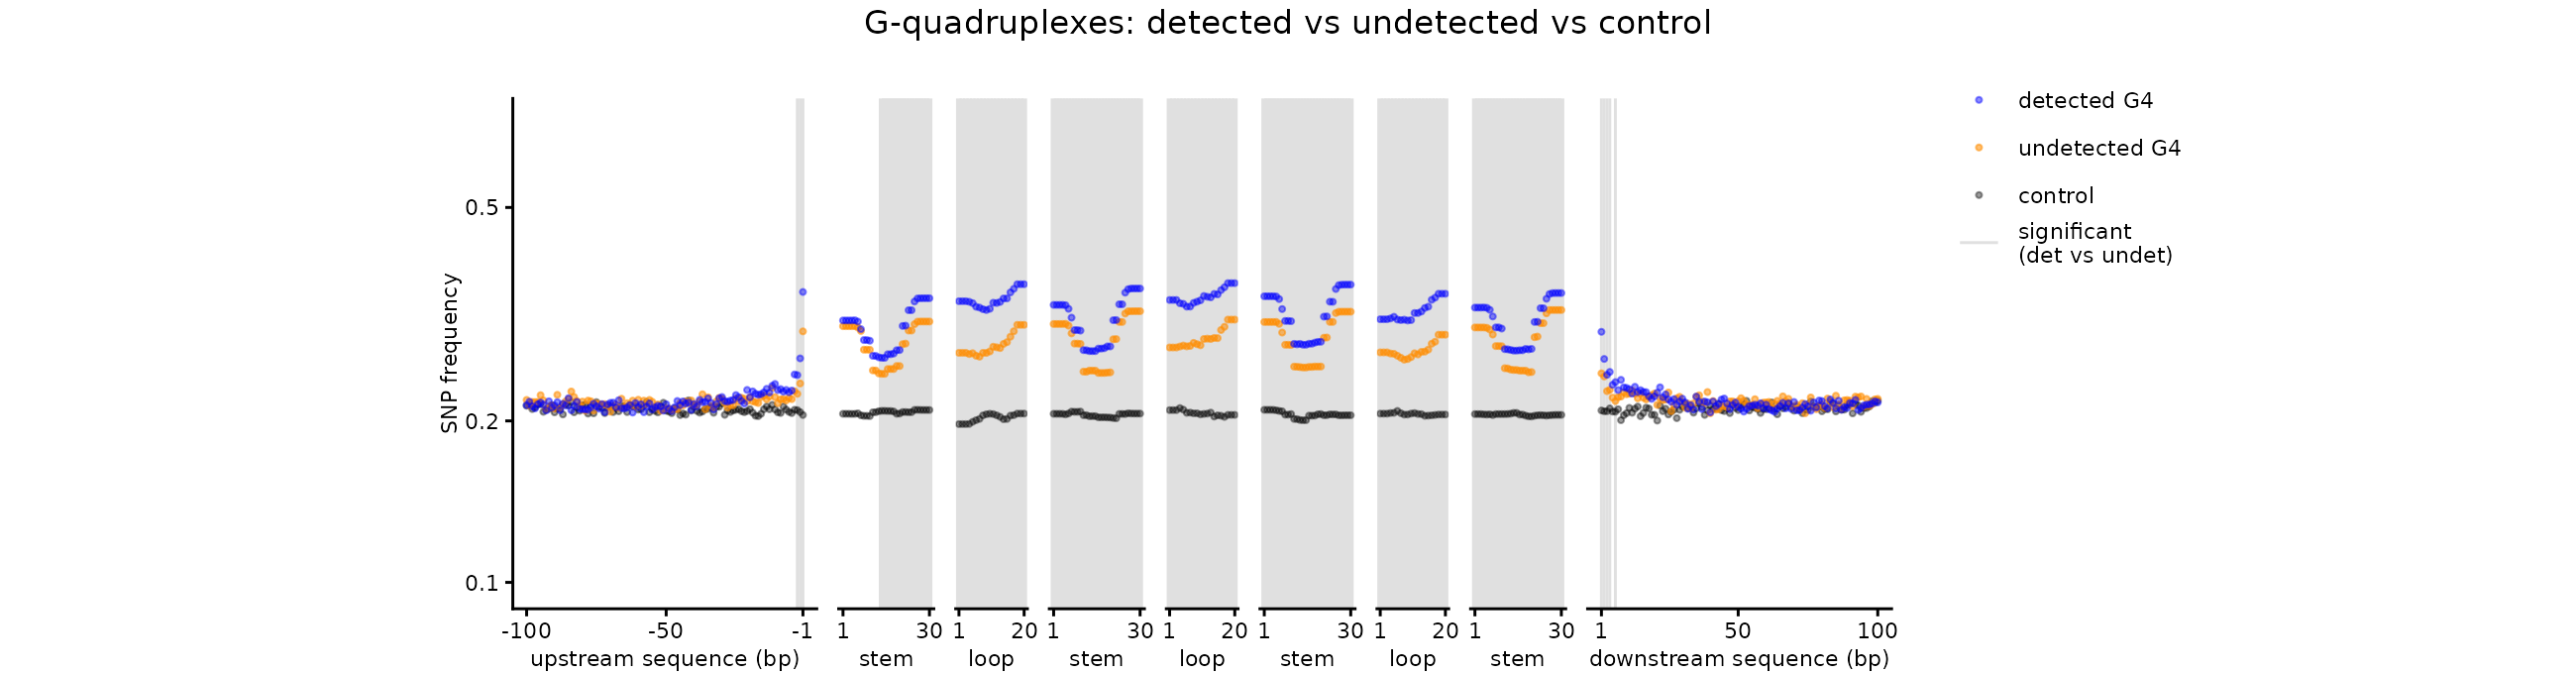

In [2]:
# R + ggplot 9-panel stem/loop plot using official IWTomics .RData (det vs undet)
# Panels: LeftFlank | stem1 | loop1 | stem2 | loop2 | stem3 | loop3 | stem4 | RightFlank
# Rebuilds per-bin SNP frequency curves for det/undet/ctrl from the
# subparts intersect files (stems scaled to 30 bins, loops to 20 bins, flanks 100 bp),
# writes freq CSVs, then plots via R + ggplot. Gray shading = official R IWTomics
# det-vs-undet significance (G4sl_detected_vs_undetected_IWTomics_*.RData).
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/g4_stemloop_run"
os.chdir(WORKDIR)

MAX_FLANK = 100; STEM_BINS = 30; LOOP_BINS = 20
CENTER_PARTS = ["stem1", "loop1", "stem2", "loop2", "stem3", "loop3", "stem4"]
SCALED_STEM = [round(i, 4) for i in np.arange(1, STEM_BINS*2, 2.0) / (STEM_BINS*2)]
SCALED_LOOP = [round(i, 4) for i in np.arange(1, LOOP_BINS*2, 2.0) / (LOOP_BINS*2)]

def _read_counts():
    out = {}
    for line in Path("split_counts.txt").read_text().strip().splitlines():
        k, v = line.split("\t"); out[k] = int(v)
    return out
_c = _read_counts()
N_MOTIF, N_CTRL = _c["N_MOTIF"], _c["N_CTRL"]
if "N_UNDET" not in _c:
    raise RuntimeError("N_UNDET not in split_counts.txt -- run run_iwtomics_g4_sl_dvu.R first")
N_UNDET = _c["N_UNDET"]
print(f"N_MOTIF={N_MOTIF}  N_UNDET={N_UNDET}  N_CTRL={N_CTRL}")

def _build_counts(intersect_path):
    cnt = {"left": np.zeros(MAX_FLANK), "right": np.zeros(MAX_FLANK)}
    for p in CENTER_PARTS:
        cnt[p] = np.zeros(STEM_BINS if "stem" in p else LOOP_BINS)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, part, snp = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, part, snp)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if part == "LeftFlank":
                idx = -(pe - snp) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: cnt["left"][idx] += 1
            elif part == "RightFlank":
                idx = snp - ps
                if 0 <= idx < MAX_FLANK: cnt["right"][idx] += 1
            elif part in cnt and plen > 0:
                scaled = SCALED_STEM if "stem" in part else SCALED_LOOP
                fs = (snp - ps) / plen; fe = (snp + 1 - ps) / plen
                for i, sp in enumerate(scaled):
                    if sp >= fs and sp < fe: cnt[part][i] += 1
    return cnt

print("counting (detected) ...");   d = _build_counts("G4sl.gnomAD.intersect")
print("counting (undetected) ..."); u = _build_counts("G4sl.gnomAD.undet.intersect")
print("counting (control) ...");    c = _build_counts("G4sl.gnomAD.shuffled.intersect")

# per-bin frequencies -> CSVs
pd.DataFrame({"DetFreq": d["left"]/N_MOTIF, "UndFreq": u["left"]/N_UNDET,
              "CtlFreq": c["left"]/N_CTRL}).to_csv("iwt_g4sl_dvu_left.csv", index=False)
pd.DataFrame({"DetFreq": d["right"]/N_MOTIF, "UndFreq": u["right"]/N_UNDET,
              "CtlFreq": c["right"]/N_CTRL}).to_csv("iwt_g4sl_dvu_right.csv", index=False)
rows = []
for p in CENTER_PARTS:
    nb = len(d[p])
    for i in range(nb):
        rows.append({"subpart": p, "bin": i+1,
                     "DetFreq": d[p][i]/N_MOTIF, "UndFreq": u[p][i]/N_UNDET,
                     "CtlFreq": c[p][i]/N_CTRL})
pd.DataFrame(rows).to_csv("iwt_g4sl_dvu_center.csv", index=False)
print("wrote iwt_g4sl_dvu_{left,right,center}.csv")

R_BIN = os.environ.get("R_BIN", "$R_BIN")
R_PLOT = r'''
suppressMessages({ library(ggplot2); library(grid); library(gridExtra) })
setwd("/path/to/snp_af_analysis/results/g4_stemloop_run")

load("G4sl_detected_vs_undetected_IWTomics_left_0.01.RData")
load("G4sl_detected_vs_undetected_IWTomics_right_0.01.RData")
load("G4sl_detected_vs_undetected_IWTomics_center_0.01.RData")

freqL <- read.csv("iwt_g4sl_dvu_left.csv")
freqR <- read.csv("iwt_g4sl_dvu_right.csv")
freqC <- read.csv("iwt_g4sl_dvu_center.csv")

CENTER_PARTS <- c("stem1","loop1","stem2","loop2","stem3","loop3","stem4")

allv <- c(freqL$DetFreq, freqL$UndFreq, freqL$CtlFreq,
          freqR$DetFreq, freqR$UndFreq, freqR$CtlFreq,
          freqC$DetFreq, freqC$UndFreq, freqC$CtlFreq)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5; y_hi <- max(allv) * 2
Y_BREAKS <- c(0.005,0.01,0.025,0.05,0.1,0.2,0.5,1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c("detected G4"   = rgb(t(col2rgb("blue")),       alpha=115, maxColorValue=255),
          "undetected G4" = rgb(t(col2rgb("darkorange")), alpha=140, maxColorValue=255),
          "control"       = rgb(t(col2rgb("black")),      alpha=100, maxColorValue=255),
          "significant\n(det vs undet)" = "grey88")

base_pts <- function(g) {
  g + geom_point(aes(y=CtlFreq, col="control"),       size=0.7) +
      geom_point(aes(y=UndFreq, col="undetected G4"), size=0.7) +
      geom_point(aes(y=DetFreq, col="detected G4"),   size=0.7) +
      theme_classic() +
      scale_colour_manual(name="", values=cols) +
      scale_y_continuous(trans="log", limits=c(y_lo,y_hi), breaks=Y_BREAKS)
}
no_y <- theme(axis.title.y=element_blank(), axis.text.y=element_blank(),
              axis.ticks.y=element_blank(), axis.line.y=element_blank())

# p1 LeftFlank
df1 <- data.frame(Levels=seq(-100,-1,1), DetFreq=freqL$DetFreq, UndFreq=freqL$UndFreq,
                  CtlFreq=freqL$CtlFreq, Signif=adj_pvalue_curve_left$significant)
p1 <- base_pts(ggplot(df1, aes(x=Levels)) +
        geom_vline(xintercept=df1$Levels[df1$Signif], col="gray88")) +
      theme(legend.position="none",
            axis.title=element_text(size=8,family="sans"),
            axis.text=element_text(size=8,family="sans")) +
      labs(y="SNP frequency", x="upstream sequence (bp)") +
      scale_x_continuous(breaks=c(-100,-50,-1), limits=c(-100,-1)) +
      theme(plot.margin=unit(c(20,4,1,1),"pt"))

# center panels (stem1..stem4)
center_panel <- function(part) {
  sub <- freqC[freqC$subpart==part, ]
  sig <- adj_pvalue_curve_center[adj_pvalue_curve_center$subpart==part, "significant"]
  nb  <- nrow(sub)
  df  <- data.frame(Levels=seq_len(nb), DetFreq=sub$DetFreq, UndFreq=sub$UndFreq,
                    CtlFreq=sub$CtlFreq, Signif=sig)
  xlab <- if (grepl("stem", part)) "stem" else "loop"
  base_pts(ggplot(df, aes(x=Levels)) +
        geom_vline(xintercept=df$Levels[df$Signif], col="gray88", linewidth=1)) +
    theme(legend.position="none",
          axis.text.x=element_text(size=8,family="sans"),
          axis.title.x=element_text(size=8,family="sans")) + no_y +
    labs(x=xlab) +
    scale_x_continuous(breaks=c(1,nb), limits=c(1,nb)) +
    theme(plot.margin=unit(c(20,4,1,4),"pt"))
}
cps <- lapply(CENTER_PARTS, center_panel)

# p9 RightFlank (carries the legend, placed outside on the right)
df9 <- data.frame(Levels=seq(1,100,1), DetFreq=freqR$DetFreq, UndFreq=freqR$UndFreq,
                  CtlFreq=freqR$CtlFreq, Signif=adj_pvalue_curve_right$significant)
p9 <- base_pts(ggplot(df9, aes(x=Levels)) +
        geom_line(aes(x=0, y=0, colour="significant\n(det vs undet)")) +
        geom_vline(xintercept=df9$Levels[df9$Signif], col="gray88")) + no_y +
      theme(axis.text.x=element_text(size=8,family="sans"),
            axis.title.x=element_text(size=8,family="sans"),
            legend.text=element_text(size=8,family="sans"),
            legend.position=c(1.55,0.90),
            legend.background=element_rect(fill="white", colour=NA)) +
      labs(x="downstream sequence (bp)") +
      scale_colour_manual(name="", values=cols,
                          breaks=c("detected G4","undetected G4","control",
                                   "significant\n(det vs undet)")) +
      scale_x_continuous(breaks=c(1,50,100), limits=c(1,100)) +
      theme(plot.margin=unit(c(20,90,1,4),"pt")) +
      guides(shape=guide_legend(order=3))

g <- arrangeGrob(grobs=c(list(p1), cps, list(p9)), ncol=9,
        widths=unit(c(50,15,12,15,12,15,12,15,72),
                    c("mm","mm","mm","mm","mm","mm","mm","mm","mm")),
        top=textGrob("G-quadruplexes: detected vs undetected vs control",
                     gp=gpar(fontsize=12, family="sans")))

ggsave("g4_stemloop_detected_vs_undetected_vs_control_iwtomics.pdf", g,
       width=13, height=3.4, dpi=300, bg="white")
ggsave("g4_stemloop_detected_vs_undetected_vs_control_iwtomics.png", g,
       width=13, height=3.4, dpi=200, bg="white")
cat("saved g4_stemloop_detected_vs_undetected_vs_control_iwtomics.{pdf,png}\n")
'''
Path("plot_g4sl_dvu_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_g4sl_dvu_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")
display(Image("g4_stemloop_detected_vs_undetected_vs_control_iwtomics.png"))
